# HW 5, Problem 1: Climatological covariance matrices

For each model we run one long simulation, discard an initial transient $[0, t_1)$, and compute the time-averaged mean and covariance on $[t_1, t_f]$:

$$\mu = \frac{1}{\Delta t}\int_{t_1}^{t_f} x(t)\,dt, \qquad B = \frac{1}{\Delta t}\int_{t_1}^{t_f} (x(t)-\mu)(x(t)-\mu)^T\,dt, \qquad \Delta t = t_f - t_1.$$

The integrals are approximated with the trapezoid rule on the sampled trajectory (`da_models.climatology`). Each $(\mu, B)$ is saved to JSON together with the parameters and settings that produced it, for reuse in Problems 3 and 5.

**Models:** Lorenz-63, one-layer Lorenz-96 ($K = 40$), and Sturis with constant glucose infusion $I_G = 216$ mg/min. With $I_G = 0$ the Sturis model sits at a stable equilibrium, so its long-time covariance is zero; the infusion puts it on a limit cycle (period about 110 min).

In [1]:
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from da_models import lorenz63, lorenz96, sturis
from da_models.climatology import (
    model_params, long_run, time_average_stats, convergence_check,
    correlation_from_covariance, save_climatology, load_climatology,
    plot_covariance_heatmaps,
)

DATA_DIR = Path("../data")   # adjust if running in Colab

## Settings

- **Initial conditions:** the spun-up ICs from HW 1 in `data/`. The Lorenz ICs are already on the attractor; the Sturis IC is the $I_G = 0$ equilibrium, so it needs a longer transient to reach the $I_G = 216$ limit cycle.
- **Discarded transient $t_1$:** 50 time units for the Lorenz models, 2000 min (about 18 cycles) for Sturis.
- **Final time $t_f$:** 5000 for the Lorenz models, 20000 min (about 180 cycles) for Sturis.
- **Sampling interval:** fine enough to resolve the dynamics (the integrator itself is adaptive, `rtol = atol = 1e-9` as in HW 1).
- **Convergence check:** compare $(\mu, B)$ computed on the two halves of $[t_1, t_f]$. Small differences mean the averages have settled.

In [2]:
MODELS = {
    "lorenz63": dict(
        rhs=lorenz63.rhs, params=model_params(lorenz63.rhs),
        t_start=50.0, t_final=5000.0, dt=0.01,
        labels=["x", "y", "z"],
    ),
    "lorenz96": dict(
        rhs=lorenz96.rhs, params=model_params(lorenz96.rhs),
        t_start=50.0, t_final=5000.0, dt=0.05,
        labels=[f"u{k+1}" for k in range(40)],
    ),
    "sturis": dict(
        rhs=sturis.rhs, params=model_params(sturis.rhs, IG=216.0),
        t_start=2000.0, t_final=20000.0, dt=0.5,
        labels=["Ip", "Ii", "G", "h1", "h2", "h3"],
    ),
}

## Long runs, statistics, and JSON output

In [3]:
results = {}
for name, cfg in MODELS.items():
    x0 = np.load(DATA_DIR / f"{name}_ic.npy")

    tic = time.perf_counter()
    t, X = long_run(cfg["rhs"], x0, cfg["t_final"], cfg["dt"], cfg["params"])
    elapsed = time.perf_counter() - tic

    mu, B = time_average_stats(t, X, cfg["t_start"])
    d_mu, d_B = convergence_check(t, X, cfg["t_start"])
    eigs = np.linalg.eigvalsh(B)

    save_climatology(
        DATA_DIR / f"climatology_{name}.json", name, mu, B,
        params=cfg["params"], state_labels=cfg["labels"],
        t_start=cfg["t_start"], t_final=cfg["t_final"], dt=cfg["dt"],
    )
    results[name] = dict(t=t, X=X, mu=mu, B=B)

    print(f"{name}  (n = {len(mu)}, run time {elapsed:.1f} s)")
    print(f"  mean of mu = {mu.mean():.4g},  ||mu|| = {np.linalg.norm(mu):.4g}")
    print(f"  eig(B): min = {eigs.min():.3e}, max = {eigs.max():.3e}, cond = {eigs.max()/eigs.min():.3e}")
    print(f"  half-window rel. diff: mu {d_mu:.2%}, B {d_B:.2%}\n")

lorenz63  (n = 3, run time 49.8 s)
  mean of mu = 7.961,  ||mu|| = 23.56
  eig(B): min = 8.504e+00, max = 1.354e+02, cond = 1.593e+01
  half-window rel. diff: mu 0.51%, B 0.41%



lorenz96  (n = 40, run time 160.6 s)
  mean of mu = 2.339,  ||mu|| = 14.8
  eig(B): min = 5.412e+00, max = 3.080e+01, cond = 5.691e+00
  half-window rel. diff: mu 1.74%, B 9.51%



sturis  (n = 6, run time 2.1 s)
  mean of mu = 2136,  ||mu|| = 1.226e+04
  eig(B): min = 1.313e-05, max = 1.324e+06, cond = 1.008e+11
  half-window rel. diff: mu 0.00%, B 0.06%



In [4]:
# Round-trip check: what Problems 3 and 5 will load
for name in MODELS:
    rec = load_climatology(DATA_DIR / f"climatology_{name}.json")
    assert np.allclose(rec["B"], results[name]["B"]) and np.allclose(rec["mu"], results[name]["mu"])
    print(f"{name}: mu {rec['mu'].shape}, B {rec['B'].shape}, saved settings t1={rec['t_start']}, tf={rec['t_final']}")

lorenz63: mu (3,), B (3, 3), saved settings t1=50.0, tf=5000.0
lorenz96: mu (40,), B (40, 40), saved settings t1=50.0, tf=5000.0
sturis: mu (6,), B (6, 6), saved settings t1=2000.0, tf=20000.0


## Lorenz-63

mu = [ 0.162  0.162 23.558]


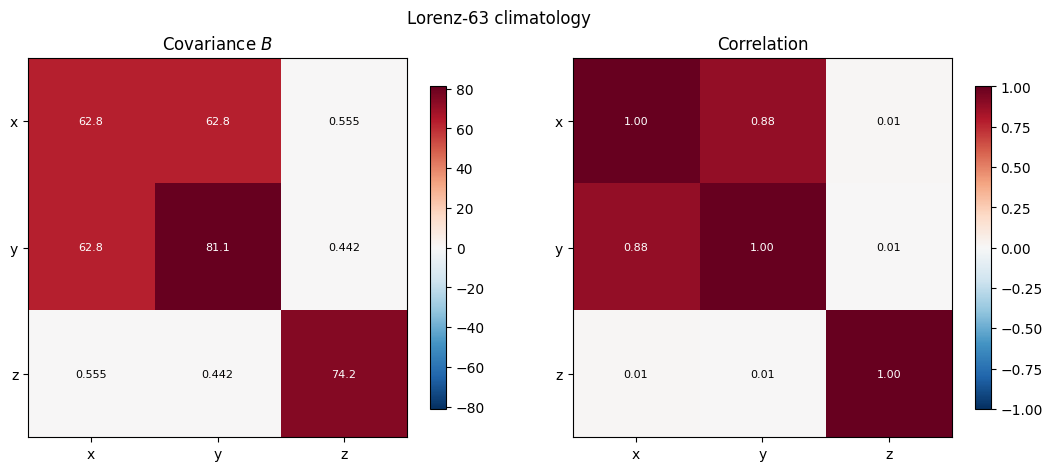

In [5]:
rec = results["lorenz63"]
print("mu =", np.round(rec["mu"], 3))
plot_covariance_heatmaps(rec["B"], MODELS["lorenz63"]["labels"], title="Lorenz-63 climatology")
plt.show()

**Discussion:** 

## Lorenz-96 (one layer, $K = 40$)

mu: mean 2.339, range [2.275, 2.386]


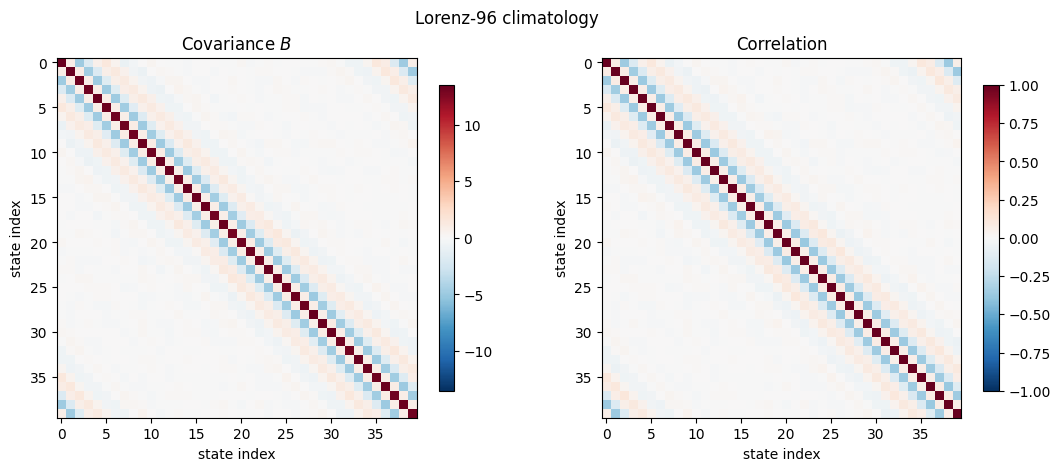

In [6]:
rec = results["lorenz96"]
print(f"mu: mean {rec['mu'].mean():.3f}, range [{rec['mu'].min():.3f}, {rec['mu'].max():.3f}]")
plot_covariance_heatmaps(rec["B"], title="Lorenz-96 climatology")
plt.show()

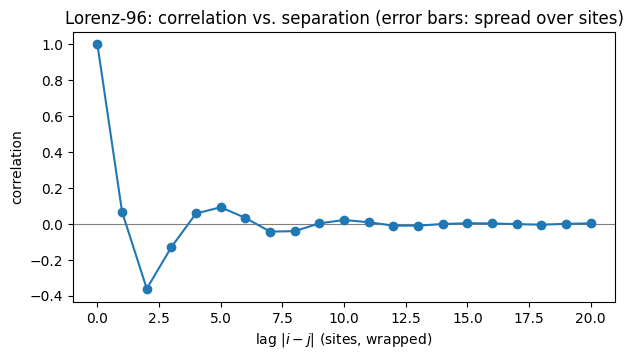

In [7]:
# Lorenz-96 is translation invariant, so correlation should depend only on the
# separation (lag) between sites. Average each wrapped diagonal of the correlation matrix.
C = correlation_from_covariance(results["lorenz96"]["B"])
K = C.shape[0]
lags = np.arange(K // 2 + 1)
by_lag = np.array([[C[i, (i + k) % K] for i in range(K)] for k in lags])

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.errorbar(lags, by_lag.mean(axis=1), yerr=by_lag.std(axis=1), marker="o", capsize=3)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("lag $|i - j|$ (sites, wrapped)")
ax.set_ylabel("correlation")
ax.set_title("Lorenz-96: correlation vs. separation (error bars: spread over sites)")
plt.show()

**Discussion:** 

## Sturis ($I_G = 216$ mg/min)

mu = [   87.13   206.08 12261.13    87.12    87.11    87.11]


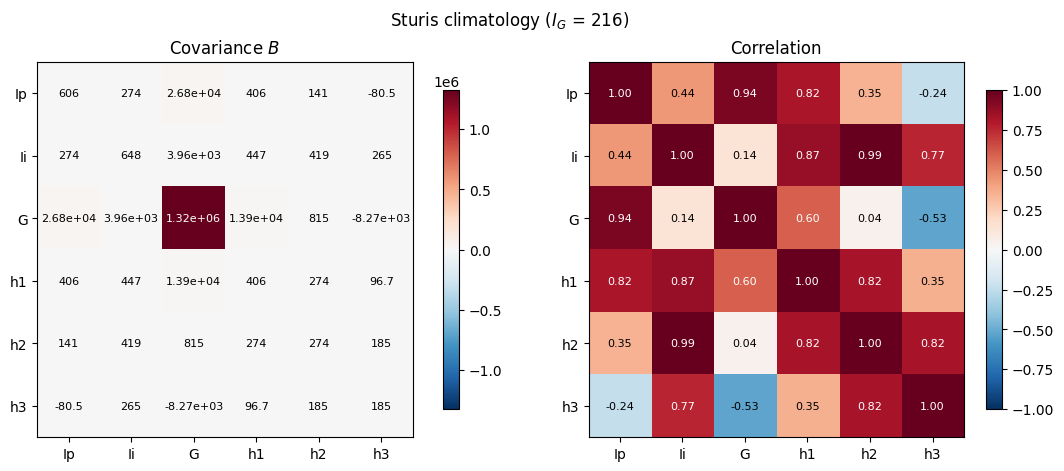

eigenvalues of the correlation matrix: [3.02243858e-08 1.05156814e-05 5.60988320e-03 7.44146637e-03
 2.33129566e+00 3.65564244e+00]


In [8]:
rec = results["sturis"]
print("mu =", np.round(rec["mu"], 2))
plot_covariance_heatmaps(rec["B"], MODELS["sturis"]["labels"], title="Sturis climatology ($I_G$ = 216)")
plt.show()

print("eigenvalues of the correlation matrix:", np.linalg.eigvalsh(correlation_from_covariance(rec["B"])))

**Discussion:** 